In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import random

In [2]:
G = pd.read_csv('calls.csv')
G = nx.from_pandas_edgelist(G, 'caller', 'callee', ['duration', 'timestamp'], create_using=nx.DiGraph())
G.remove_edges_from(nx.selfloop_edges(G))
isolated = list(nx.isolates(G))
G.remove_nodes_from(isolated)
threshold = 0.5
edges_to_remove = [(u, v) for u, v, d in G.edges(data=True) if d.get("weight", 1) < threshold]
G.remove_edges_from(edges_to_remove)

In [3]:
def get_largest_component(G):
    """
    Returns the largest connected component subgraph.
    Works for both directed and undirected graphs.
    """
    if G.is_directed():
        # Use weakly connected components for spread (ignores direction)
        largest_cc = max(nx.weakly_connected_components(G), key=len)
    else:
        largest_cc = max(nx.connected_components(G), key=len)
    return G.subgraph(largest_cc).copy()

In [4]:
def pick_random_seed(G):
    G_lcc = get_largest_component(G)
    seed = random.choice(list(G_lcc.nodes()))
    return seed, G_lcc

In [5]:
def simulate_si_model(G_lcc, seed, beta=0.2, steps=50):
    state = {n: 0 for n in G_lcc.nodes()}
    state[seed] = 1

    S, I = [], []

    for _ in range(steps):
        new_state = state.copy()
        for node in G_lcc.nodes():
            if state[node] == 1:
                for neigh in G_lcc.neighbors(node):
                    if state[neigh] == 0 and random.random() < beta:
                        new_state[neigh] = 1
        state = new_state
        S.append(sum(v == 0 for v in state.values()))
        I.append(sum(v == 1 for v in state.values()))

    return S, I

In [6]:
def simulate_sis_model(G_lcc, seed, beta=0.3, gamma=0.1, steps=60):
    state = {n: 0 for n in G_lcc.nodes()}
    state[seed] = 1

    S, I = [], []

    for _ in range(steps):
        new_state = state.copy()
        for node in G_lcc.nodes():
            if state[node] == 1:
                for neigh in G_lcc.neighbors(node):
                    if state[neigh] == 0 and random.random() < beta:
                        new_state[neigh] = 1
                if random.random() < gamma:
                    new_state[node] = 0
        state = new_state
        S.append(sum(v == 0 for v in state.values()))
        I.append(sum(v == 1 for v in state.values()))

    return S, I

In [7]:
def simulate_sic_model(G_lcc, seed, beta=0.3, gamma=0.05, steps=50):
    state = {n: 0 for n in G_lcc.nodes()}
    state[seed] = 1

    S, I, C = [], [], []

    for _ in range(steps):
        new_state = state.copy()
        for node in G_lcc.nodes():
            if state[node] in [1, 2]:
                for neigh in G_lcc.neighbors(node):
                    if state[neigh] == 0 and random.random() < beta:
                        new_state[neigh] = 1
            if state[node] == 1 and random.random() < gamma:
                new_state[node] = 2
        state = new_state

        S.append(sum(v == 0 for v in state.values()))
        I.append(sum(v == 1 for v in state.values()))
        C.append(sum(v == 2 for v in state.values()))

    return S, I, C

In [8]:
def simulate_sir_model(G_lcc, seed, beta=0.3, gamma=0.05, steps=50):
    state = {n: 0 for n in G_lcc.nodes()}
    state[seed] = 1

    S, I, R = [], [], []

    for _ in range(steps):
        new_state = state.copy()
        for node in G_lcc.nodes():
            if state[node] == 1:
                for neigh in G_lcc.neighbors(node):
                    if state[neigh] == 0 and random.random() < beta:
                        new_state[neigh] = 1
                if random.random() < gamma:
                    new_state[node] = 2
        state = new_state

        S.append(sum(v == 0 for v in state.values()))
        I.append(sum(v == 1 for v in state.values()))
        R.append(sum(v == 2 for v in state.values()))

    return S, I, R

In [9]:
def makeNiceFigure(G_lcc, seed,beta,gamma,steps):
    plt.figure(figsize=(20,5))
    plt.subplot(1,4,1)
    S, I = simulate_si_model(G_lcc=G_lcc, seed=seed,beta=beta,steps=steps)
    plt.plot(S, label="Susceptible")
    plt.plot(I, label="Infected (hoax spreaders)")
    plt.xlabel("Time step")
    plt.ylabel("Number of nodes")
    plt.legend()
    plt.title("SI model")
    plt.grid(visible=True)

    plt.subplot(1,4,2)
    S, I = simulate_sis_model(G_lcc=G_lcc, seed=seed,beta=beta,gamma=gamma,steps=steps)
    plt.plot(S, label="Susceptible")
    plt.plot(I, label="Infected (hoax spreaders)")
    plt.xlabel("Time step")
    plt.ylabel("Number of nodes")
    plt.legend()
    plt.title("SIS model")
    plt.grid(visible=True)

    plt.subplot(1,4,3)
    S, I, C = simulate_sic_model(G_lcc=G_lcc, seed=seed,beta=beta,gamma=gamma,steps=steps)
    plt.plot(S, label="Susceptible")
    plt.plot(I, label="Infected (hoax spreaders)")
    plt.plot(C, label="Carrier")
    plt.xlabel("Time step")
    plt.ylabel("Number of nodes")
    plt.legend()
    plt.title("SIC model")
    plt.grid(visible=True)

    plt.subplot(1,4,4)
    S, I, R = simulate_sir_model(G_lcc=G_lcc, seed=seed, beta=beta, gamma=gamma, steps=steps)
    plt.plot(S, label="Susceptible")
    plt.plot(I, label="Infected (hoax spreaders)")
    plt.plot(R, label="Recovered")
    plt.xlabel("Time step")
    plt.ylabel("Number of nodes")
    plt.legend()
    plt.title("SIR model")
    plt.grid(visible=True)
    plt.show();

All models with 25% chance to spread


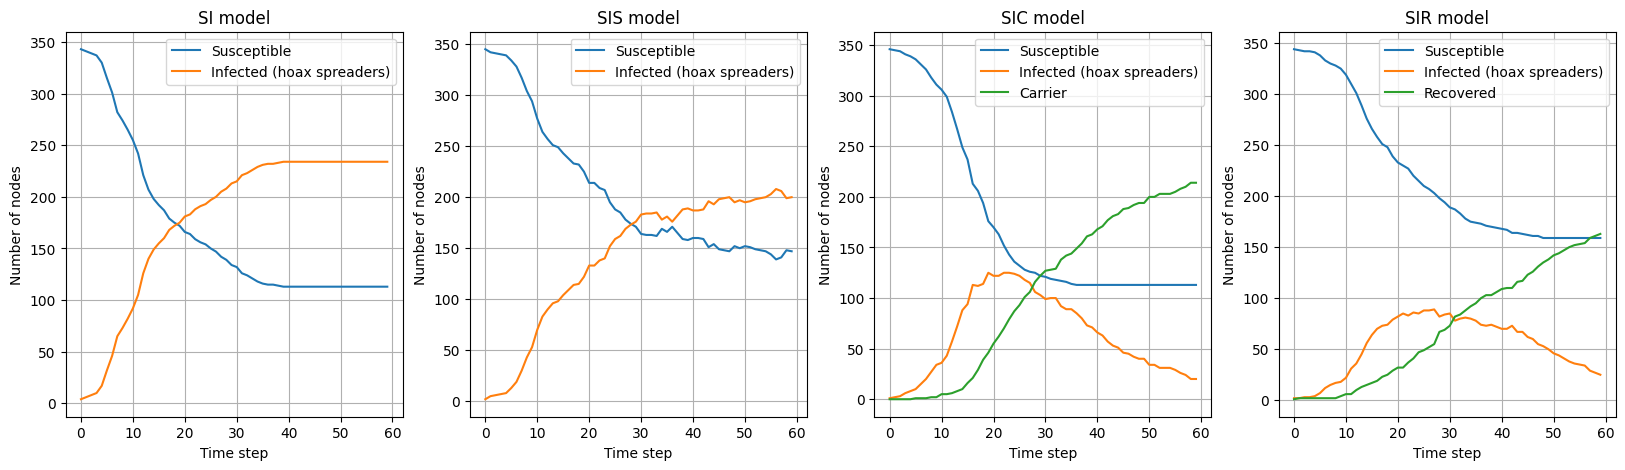

All models with 50% chance to spread


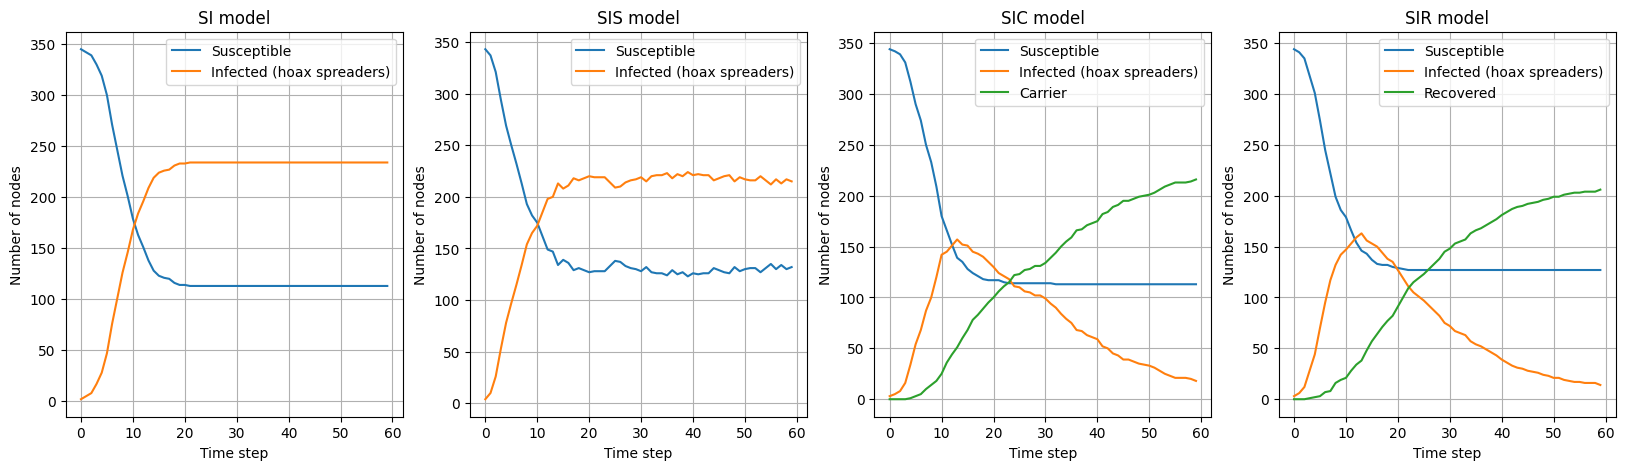

All models with 75% chance to spread


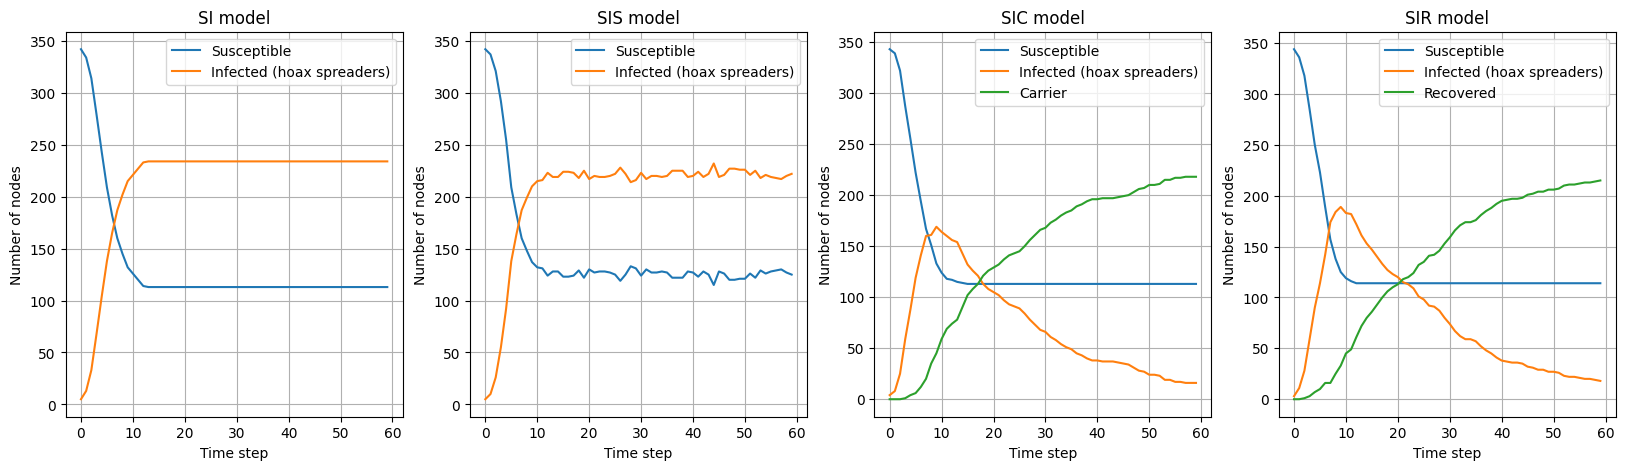

In [10]:
seed, G_lcc = pick_random_seed(G)

numSteps=60

print('All models with 25% chance to spread')
makeNiceFigure(G_lcc, seed,beta=0.25,gamma=0.05,steps=numSteps)
print('All models with 50% chance to spread')
makeNiceFigure(G_lcc, seed,beta=0.5,gamma=0.05,steps=numSteps)
print('All models with 75% chance to spread')
makeNiceFigure(G_lcc, seed,beta=0.75,gamma=0.05,steps=numSteps)